<a href="https://colab.research.google.com/github/Srivaibhav4014e/Data-science-/blob/main/Full%20EDA%20on%20iris%20dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (150, 5)

First 5 rows:
    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Data types:
 sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Missing values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Class distribution:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Descriptive Statistics:
       sepal_length  sepal_width  petal_length  petal_width
count        150.00       150.00        150.00       150.00
mean           5.84         3.06          3.76         1.20
std

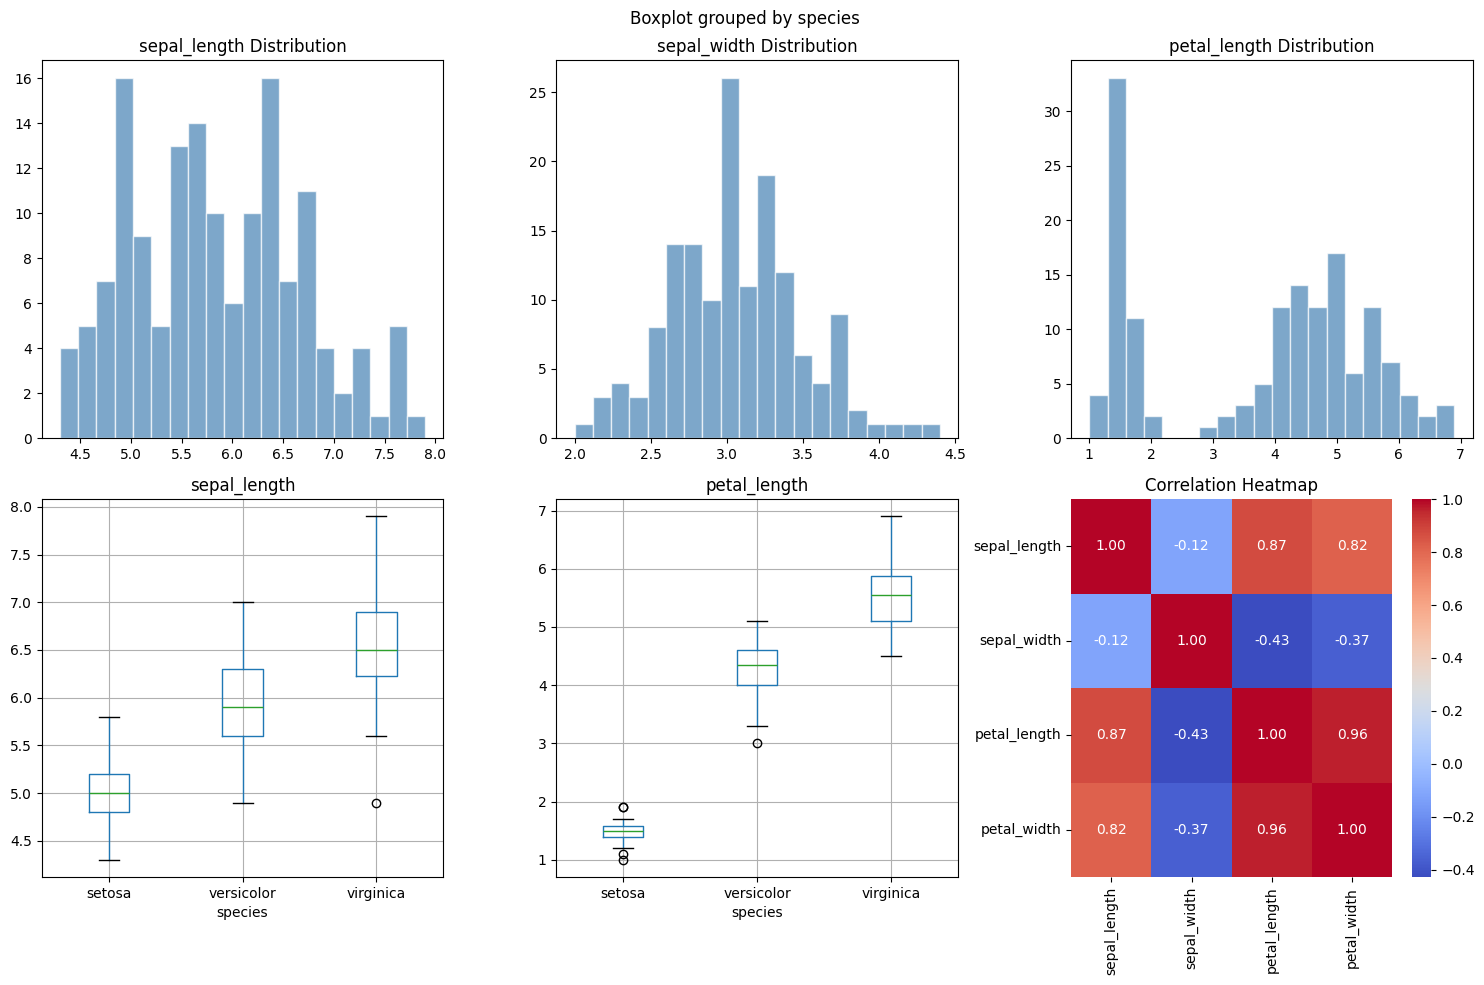


t-statistic: -15.3862
p-value:     0.000000
Result: Significant difference (reject H₀)


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Load Data ────────────────────────────────────
df = sns.load_dataset('iris')

# ── Step 1: Understand the data ──────────────────
print('Shape:', df.shape)             # (150, 5)
print('\nFirst 5 rows:\n', df.head())
print('\nData types:\n', df.dtypes)
print('\nMissing values:\n', df.isnull().sum())
print('\nClass distribution:\n', df['species'].value_counts())

# ── Step 2: Univariate Analysis ──────────────────
print('\nDescriptive Statistics:')
print(df.describe().round(2))

# ── Step 3: Grouped Statistics ───────────────────
print('\nStatistics by Species:')
print(df.groupby('species').agg(
    {'sepal_length':['mean','std','min','max'],
     'petal_length':['mean','std']}).round(2))

# ── Step 4: Correlation ──────────────────────────
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
print('\nCorrelation Matrix:\n', corr.round(2))

# ── Step 5: Visualizations ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Iris Dataset EDA', fontsize=16)

# Distribution
for col, ax in zip(numeric_df.columns, axes[0]):
    ax.hist(numeric_df[col], bins=20, edgecolor='white',
            color='steelblue', alpha=0.7)
    ax.set_title(f'{col} Distribution')

# Box plots by species
df.boxplot(column='sepal_length', by='species', ax=axes[1,0])
df.boxplot(column='petal_length', by='species', ax=axes[1,1])

# Correlation Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1,2], fmt='.2f')
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout(); plt.show()

# ── Step 6: Statistical Inference (t-test) ───────
setosa    = df[df['species']=='setosa']['sepal_length']
virginica = df[df['species']=='virginica']['sepal_length']

t_stat, p_value = stats.ttest_ind(setosa, virginica)
print(f'\nt-statistic: {t_stat:.4f}')
print(f'p-value:     {p_value:.6f}')
if p_value < 0.05:
    print('Result: Significant difference (reject H₀)')
else:
    print('Result: No significant difference (fail to reject H₀)')